# Clinical Trial Dropout Risk Prediction

**Objective.** 
This project aimed to explore a synthetic clinical trial dataset to identify potential factors associated with participant dropout and to build a predictive model capable of flagging at-risk participants, using dropout prevention as the guiding clinical priority.

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import scipy.stats as stats

In [65]:
#import dataframe
df = pd.read_csv("synthetic_clinical_trial_data.csv")
display(df)

,Subject_ID,Site_ID,Age,Gender,Enrollment_Date,Treatment_Group,Adverse_Events,Dropout,Systolic_BP,Diastolic_BP,Cholesterol_Level
0,1,49,54,Male,1/1/22,Drug A,0,0,117,74,229
1,2,37,44,Male,1/2/22,Placebo,1,0,111,57,173
2,3,1,58,Male,1/3/22,Drug A,0,1,122,89,220
3,4,25,48,Male,1/4/22,Drug B,0,0,122,85,175
4,5,10,57,Female,1/5/22,Drug A,2,0,105,90,185
...,...,...,...,...,...,...,...,...,...,...,...
995,996,50,43,Male,9/22/24,Placebo,0,0,119,73,234
996,997,23,14,Female,9/23/24,Drug A,0,1,110,93,232
997,998,42,65,Female,9/24/24,Placebo,0,0,135,95,188
998,999,38,65,Male,9/25/24,Drug B,0,0,137,91,211


In [66]:
#number of rows and columns
print(df.shape)

#column information
print(df.info())

(1000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Subject_ID         1000 non-null   int64
 1   Site_ID            1000 non-null   int64
 2   Age                1000 non-null   int64
 3   Gender             1000 non-null   str  
 4   Enrollment_Date    1000 non-null   str  
 5   Treatment_Group    1000 non-null   str  
 6   Adverse_Events     1000 non-null   int64
 7   Dropout            1000 non-null   int64
 8   Systolic_BP        1000 non-null   int64
 9   Diastolic_BP       1000 non-null   int64
 10  Cholesterol_Level  1000 non-null   int64
dtypes: int64(8), str(3)
memory usage: 86.1 KB
None


## Data Preparation

Before starting the exploratory data analysis, the "Enrollment_Date" column was converted to a datetime format. This allows the extraction of temporal features, such as the enrollment month, for later analysis.

In [67]:
#convert to a datetime format
df["Enrollment_Date"] = pd.to_datetime(df["Enrollment_Date"], format='%m/%d/%y')

### Dataset Structure

In [68]:
#column information
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Subject_ID         1000 non-null   int64         
 1   Site_ID            1000 non-null   int64         
 2   Age                1000 non-null   int64         
 3   Gender             1000 non-null   str           
 4   Enrollment_Date    1000 non-null   datetime64[us]
 5   Treatment_Group    1000 non-null   str           
 6   Adverse_Events     1000 non-null   int64         
 7   Dropout            1000 non-null   int64         
 8   Systolic_BP        1000 non-null   int64         
 9   Diastolic_BP       1000 non-null   int64         
 10  Cholesterol_Level  1000 non-null   int64         
dtypes: datetime64[us](1), int64(8), str(2)
memory usage: 86.1 KB
None


### Descriptive Statistics

In [69]:
#descriptive statistics of the dataframe
df.describe()

,Subject_ID,Site_ID,Age,Enrollment_Date,Adverse_Events,Dropout,Systolic_BP,Diastolic_BP,Cholesterol_Level
count,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,26.702000,50.447000,2023-05-15 12:00:00,1.046000,0.161000,119.544000,80.190000,200.339000
min,1.000000,1.000000,6.000000,2022-01-01 00:00:00,0.000000,0.000000,73.000000,47.000000,83.000000
25%,250.750000,15.000000,39.000000,2022-09-07 18:00:00,0.000000,0.000000,109.000000,73.000000,179.000000
50%,500.500000,27.000000,51.000000,2023-05-15 12:00:00,1.000000,0.000000,119.000000,80.000000,200.000000
75%,750.250000,38.250000,61.000000,2024-01-20 06:00:00,2.000000,0.000000,129.000000,87.000000,220.000000
max,1000.000000,50.000000,98.000000,2024-09-26 00:00:00,15.000000,1.000000,200.000000,120.000000,350.000000
std,288.819436,14.104614,15.383427,NaN,1.424048,0.367715,15.819618,10.576567,31.744224


Summary statistics were generated for the numerical variables to better understand their distributions, central tendency, and variability.

# Exploratory Data Analysis

## Target Variable
Knowing the target variable: Dropout

In [70]:
#value counts of the target variable
df['Dropout'].value_counts()


Dropout
0    839
1    161
Name: count, dtype: int64

In [71]:
#proportion of the target variable
df['Dropout'].value_counts(normalize=True) * 100


Dropout
0    83.9
1    16.1
Name: proportion, dtype: float64

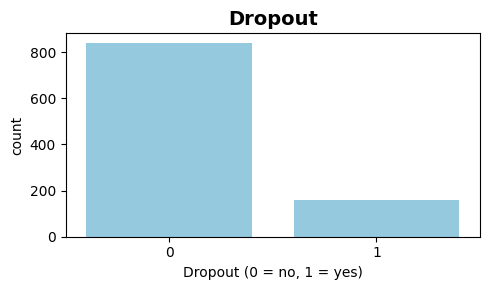

In [72]:
#countplot of the target variable
plt.figure(figsize=(5, 3))
plt.title("Dropout", fontsize=14, fontweight="bold")
sns.countplot(x=df["Dropout"], color="skyblue")
plt.xlabel("Dropout (0 = no, 1 = yes)")
plt.tight_layout()
plt.show()

An imbalance between the classes is observed, with a predominance of participants who completed the clinical trial.

## Categorical Variables

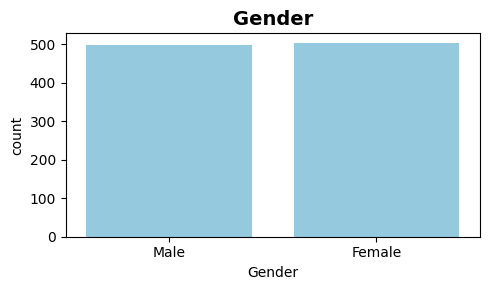

In [73]:
#count plot of Gender
plt.figure(figsize=(5, 3))
plt.title("Gender", fontsize=14, fontweight="bold")
sns.countplot(x=df["Gender"], color="skyblue")
plt.tight_layout()
plt.show()

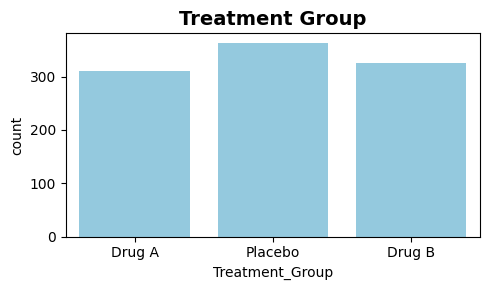

In [74]:
#count plot of Treatment Group
plt.figure(figsize=(5, 3))
plt.title("Treatment Group", fontsize=14, fontweight="bold")
sns.countplot(x=df["Treatment_Group"], color="skyblue")
plt.tight_layout()
plt.show()

## Numerical Variables

In [75]:
#removing identifier and categorical columns to isolate numeric features
numeric_features = df.drop(columns=["Subject_ID", "Enrollment_Date", "Site_ID", "Dropout", "Gender", "Treatment_Group"])

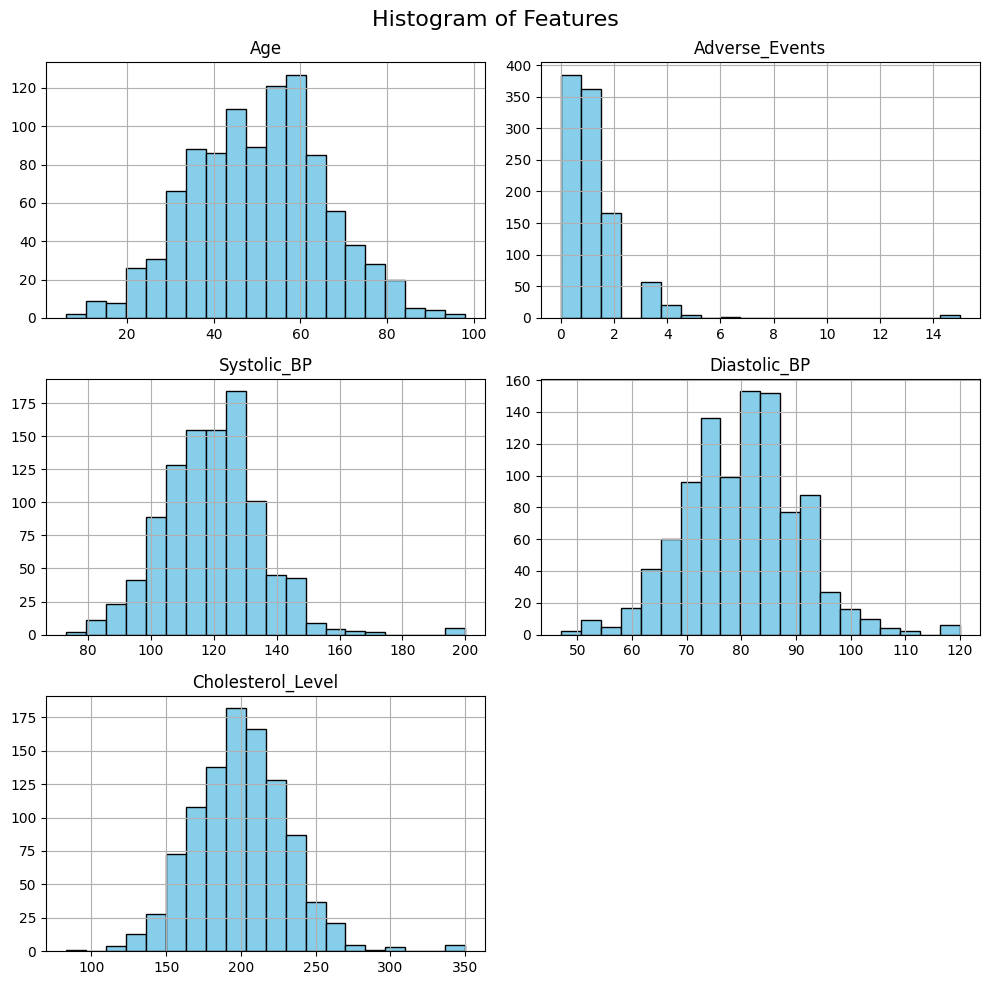

In [76]:
#histogram of features
numeric_features.hist(bins=20, figsize=(10, 10), color="skyblue", edgecolor="black")
plt.suptitle("Histogram of Features", fontsize=16)
plt.tight_layout()
plt.show()

The gender variable is balanced, with approximately equal numbers of male and female participants. The treatment groups are relatively balanced, although the placebo group contains slightly more participants than the two treatment groups. Most continuous variables (Age, Systolic_BP, Diastolic_BP, and Cholesterol_Level) show approximately normal distributions. In contrast, Adverse_Events presents a right-skewed distribution, with most participants experiencing few or no adverse events and a small number presenting higher counts. A few potential outliers are observed in the blood pressure and cholesterol variables.

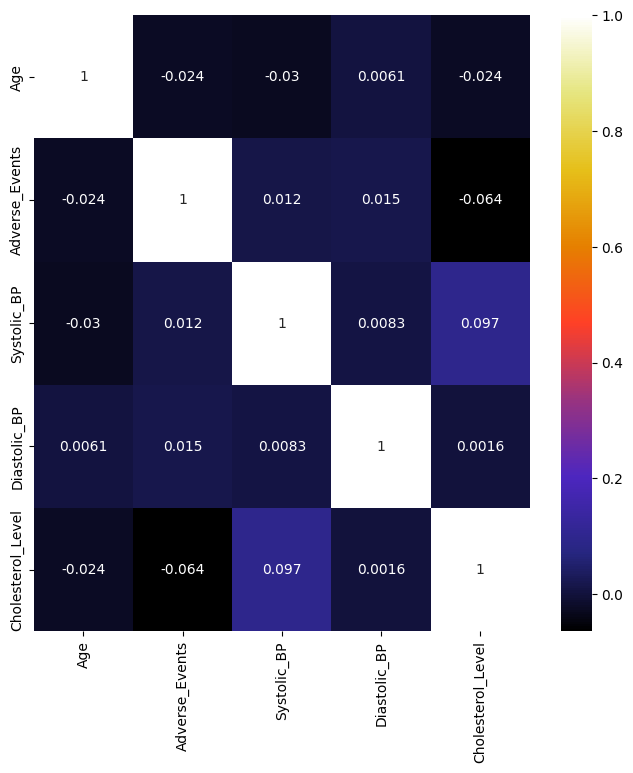

In [77]:
#heatmap of numeric features 
plt.figure(figsize=(8,8))
sns.heatmap(numeric_features.corr(), cmap="CMRmap",annot=True)
plt.show()

The correlation heatmap shows weak linear relationships among the numerical variables. All correlation coefficients are close to zero, indicating that there are no strong linear associations between these variables.

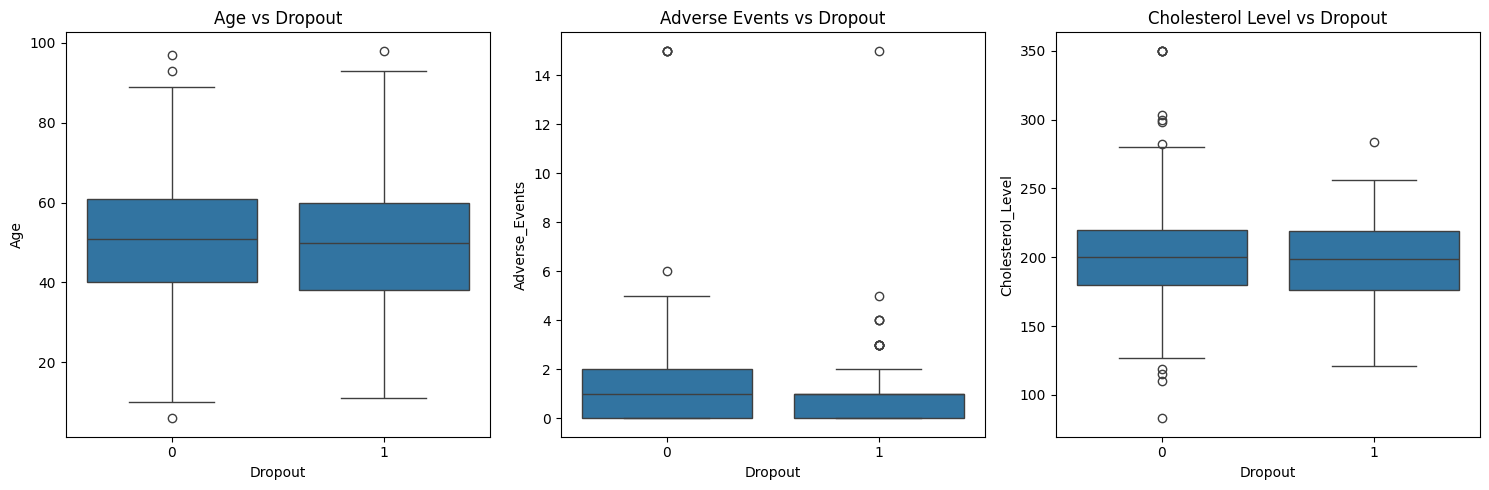

In [78]:
#boxplot of features vs dropout
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#age
sns.boxplot(x="Dropout", y="Age", data=df, ax=axes[0])
axes[0].set_title("Age vs Dropout")

#adverse events
sns.boxplot(x="Dropout", y="Adverse_Events", data=df, ax=axes[1])
axes[1].set_title("Adverse Events vs Dropout")

#cholesterol level
sns.boxplot(x="Dropout", y="Cholesterol_Level", data=df, ax=axes[2])
axes[2].set_title("Cholesterol Level vs Dropout")

plt.tight_layout()
plt.show()

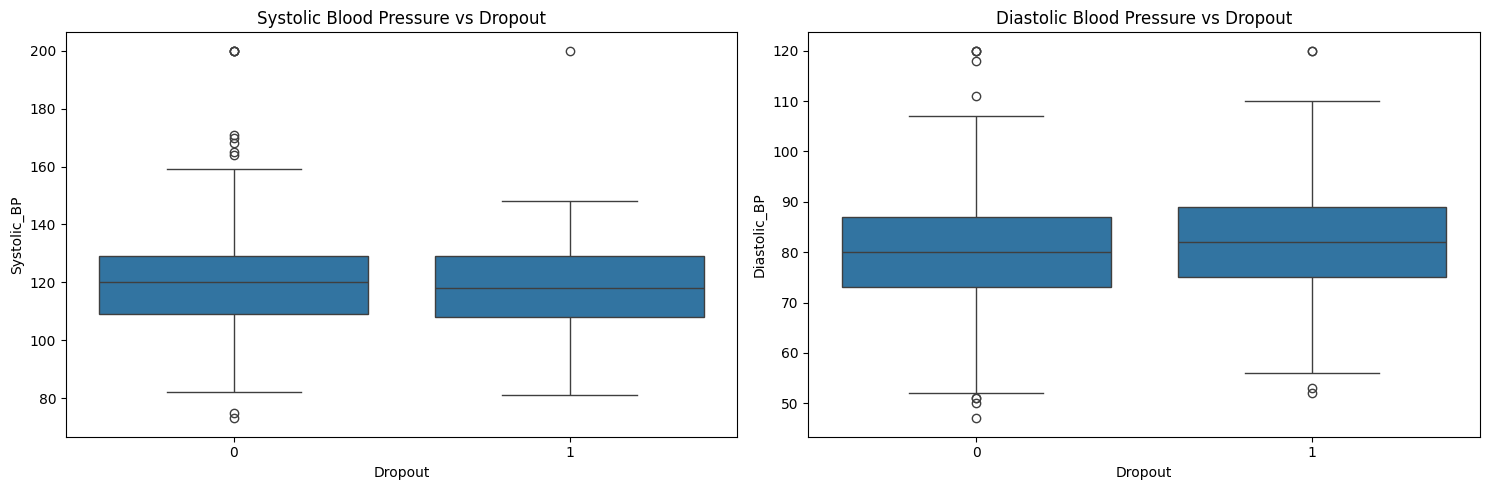

In [79]:
#boxplot of blood pressure vs dropout
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#blood pressure
sns.boxplot(x="Dropout", y="Systolic_BP", data=df, ax=axes[0])
axes[0].set_title("Systolic Blood Pressure vs Dropout")


sns.boxplot(x="Dropout", y="Diastolic_BP", data=df, ax=axes[1])
axes[1].set_title("Diastolic Blood Pressure vs Dropout")


plt.tight_layout()
plt.show()

The boxplots suggest that the distributions of Age, Adverse Events, Blood Pressure, and Cholesterol Level are similar between participants who completed the study and those who dropped out. No clear visual differences are observed, indicating that these variables alone may not be strong predictors of dropout in this synthetic dataset.

In [80]:
#comparing the mean of numerical variables between participants who dropped out and who didn't
df.groupby("Dropout")[[
    "Age",
    "Adverse_Events",
    "Systolic_BP",
    "Diastolic_BP",
    "Cholesterol_Level"
]].mean()

,Age,Adverse_Events,Systolic_BP,Diastolic_BP,Cholesterol_Level
Dropout,,,,,
0,50.678188,1.066746,119.792610,79.866508,200.846246
1,49.242236,0.937888,118.248447,81.875776,197.695652


In [81]:
#running independent t-tests to check if each numerical variable differs significantly between the two groups
from scipy.stats import ttest_ind

variables = [
    "Age",
    "Adverse_Events",
    "Systolic_BP",
    "Diastolic_BP",
    "Cholesterol_Level"
]

for var in variables:
    #splitting the variable into two groups based on dropout status
    group0 = df[df["Dropout"] == 0][var]
    group1 = df[df["Dropout"] == 1][var]
    
    #testing if the means of the two groups are significantly different
    t_stat, p_value = ttest_ind(group0, group1)

    print(f"\n{var}")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Statistically significant")
    else:
        print("Not statistically significant")


Age
T-statistic: 1.0850
P-value: 0.2782
Not statistically significant

Adverse_Events
T-statistic: 1.0517
P-value: 0.2932
Not statistically significant

Systolic_BP
T-statistic: 1.1346
P-value: 0.2568
Not statistically significant

Diastolic_BP
T-statistic: -2.2122
P-value: 0.0272
Statistically significant

Cholesterol_Level
T-statistic: 1.1537
P-value: 0.2489
Not statistically significant


In [82]:
#checking mean, std and median of diastolic BP by group for more detail
df.groupby("Dropout")["Diastolic_BP"].agg(["mean","std","median"])

,mean,std,median
Dropout,,,
0,79.866508,10.360740,80.0
1,81.875776,11.524842,82.0


Independent t-tests were performed to compare the numerical variables between participants who completed the study and those who dropped out. Among the five numerical variables analyzed, only Diastolic Blood Pressure showed a statistically significant difference between the two groups (t = -2.21, p = 0.0272). Participants who dropped out had a slightly higher mean diastolic blood pressure (81.88 mmHg) than those who completed the study (79.87 mmHg). However, the observed difference was small (approximately 2 mmHg), suggesting limited practical significance. The remaining variables showed no statistically significant differences (p > 0.05).

# Descriptive Variables

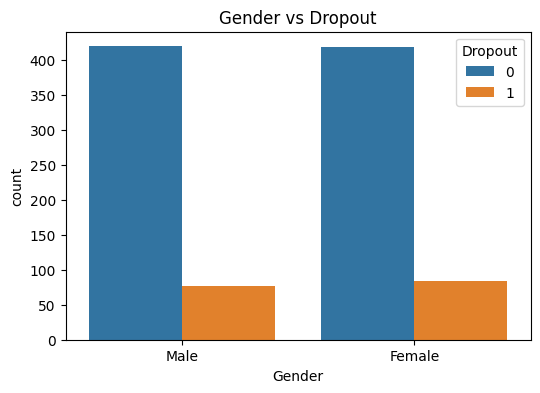

In [83]:
#gender vs dropout count plot
plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", hue="Dropout", data=df)
plt.title("Gender vs Dropout")
plt.show()

The distribution of dropout is similar between male and female participants. No substantial differences are observed. 

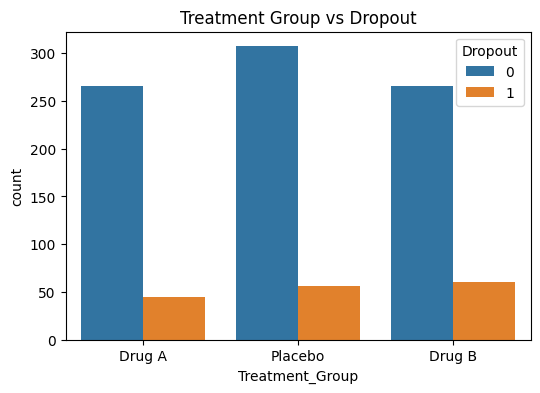

In [84]:
#treatment group vs dropout count plot
plt.figure(figsize=(6, 4))
sns.countplot(x="Treatment_Group", hue="Dropout", data=df)
plt.title("Treatment Group vs Dropout")
plt.show()

In [85]:
#proportion of gender between participants who dropped out and who didn't
pd.crosstab(df["Gender"], df["Dropout"], normalize="index") * 100

Dropout,0,1
Gender,,
Female,83.300199,16.699801
Male,84.507042,15.492958


In [86]:
#proportion of treatment group between participants who dropped out and who didn't
pd.crosstab(df["Treatment_Group"], df["Dropout"], normalize="index") * 100

Dropout,0,1
Treatment_Group,,
Drug A,85.530547,14.469453
Drug B,81.595092,18.404908
Placebo,84.573003,15.426997


The dropout rate appears slightly higher in the Drug B group (18.4%) compared with Drug A (14.5%) and the Placebo group (15.4%). However, the difference is relatively small, and further statistical analysis would be required to determine whether it is significant.

In [87]:
#create the contingency table by crossing the two columns
#this will count how many men/women abandoned the course or not
contingency_table = pd.crosstab(df['Gender'], df['Dropout'])

#view the generated count matrix:
display(contingency_table)

#run the test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

Dropout,0,1
Gender,,
Female,419,84
Male,420,77


Chi-Square Statistic: 0.1876
P-value: 0.6649
Degrees of freedom: 1


The Chi-square test was performed to evaluate whether there is an association between Gender and Dropout. This test assesses whether two categorical variables are independent.

The results indicate no statistically significant association between Gender and Dropout (χ² = 0.1876, p = 0.6649). Since the p-value is greater than 0.05, we fail to reject the null hypothesis, suggesting that gender is not associated with participant dropout in this dataset.

In [88]:
#create the contingency table by crossing the two columns
#this will count how many people dropped out or not according to treatment group
contingency_table2 = pd.crosstab(df["Treatment_Group"], df['Dropout'])

#view the generated count matrix:
display(contingency_table2)

#run the test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table2)

#results
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

Dropout,0,1
Treatment_Group,,
Drug A,266,45
Drug B,266,60
Placebo,307,56


Chi-Square Statistic: 2.0160
P-value: 0.3650
Degrees of freedom: 2


The Chi-square test was performed to evaluate whether there is an association between Treatment Group and Dropout.

The results indicate no statistically significant association between Treatment Group and participant dropout (χ² = 2.0160, p = 0.3650). Although the Drug B group showed a slightly higher dropout rate than the other groups, this difference was not statistically significant (p > 0.05). Therefore, we fail to reject the null hypothesis, suggesting that treatment group is not associated with dropout in this dataset.

In [89]:
#extracting enrollment month and testing if it's associated with dropout
df["Enrollment_Month"] = df["Enrollment_Date"].dt.month
from scipy.stats import chi2_contingency

table_enrollment_dropout= pd.crosstab(df["Enrollment_Month"], df["Dropout"])

chi2, p, dof, expected = chi2_contingency(table_enrollment_dropout)

print(p)

0.3362649708440947


In [90]:
#checking if Subject_ID is just an identifier (no analytical value)
df["Subject_ID"].head()

0    1
1    2
2    3
3    4
4    5
Name: Subject_ID, dtype: int64

Since machine learning models cannot directly use datetime variables, the enrollment date was further investigated. The month of enrollment was extracted and tested for association with the target variable (Dropout) using a Chi-square test. No statistically significant association was observed (p = 0.336), indicating that the enrollment month did not provide relevant predictive information. Therefore, the Enrollment_Date variable will be removed before model training.

The "Subject ID" variable will also be removed, since it is merely an identifier.

# Model Training

In [91]:
#splitting data into train and test sets for modeling
from sklearn.model_selection import train_test_split
#y -> this is the column in the dataset that I want to predict.
y = df["Dropout"]

#x -> the columns of the dataset that I will use to make the prediction
x = df.drop(columns=["Dropout", "Subject_ID", "Enrollment_Date", "Enrollment_Month"])

#create the test and train
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [92]:
#checking shapes of X and y, and confirming train/test splits are consistent
print(f"X: {x.shape}")
print(f"y: {y.shape}")

print(f"X_train: {x_train.shape}")
print(f"X_test: {x_test.shape}")

print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print("\nChecks:")
print(f"X and y have the same number of rows? {x.shape[0] == y.shape[0]}")
print(f"X_train and y_train have the same number of rows? {x_train.shape[0] == y_train.shape[0]}")
print(f"X_test and y_test have the same number of rows? {x_test.shape[0] == y_test.shape[0]}")

X: (1000, 8)
y: (1000,)
X_train: (800, 8)
X_test: (200, 8)
y_train: (800,)
y_test: (200,)

Checks:
X and y have the same number of rows? True
X_train and y_train have the same number of rows? True
X_test and y_test have the same number of rows? True


The dataset was successfully divided into predictor variables (X) and the target variable (y), where Dropout was defined as the prediction target. An 80/20 train-test split was then applied, resulting in 800 training observations and 200 testing observations. A verification confirmed that the predictor and target datasets remained aligned after the split, ensuring that each observation had a corresponding target value.

### One-Hot Encoding

In [93]:
#one-hot encoding categorical variables (Gender, Treatment_Group) into numeric dummy variables
x_train = pd.get_dummies(
    x_train,
    columns=["Gender", "Treatment_Group"],
    drop_first=True
)

x_test = pd.get_dummies(
    x_test,
    columns=["Gender", "Treatment_Group"],
    drop_first=True
)

Machine learning algorithms require numerical input variables. Therefore, the categorical variables ("Gender" and "Treatment_Group") were transformed into binary indicator variables using One-Hot Encoding.

In [ ]:
#checking if x_test has the same columns as x_train and filling missing ones with 0
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

In [95]:
#checking column types and confirming all variables are now numeric after encoding
x_train.info()

<class 'pandas.DataFrame'>
Index: 800 entries, 29 to 102
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Site_ID                  800 non-null    int64
 1   Age                      800 non-null    int64
 2   Adverse_Events           800 non-null    int64
 3   Systolic_BP              800 non-null    int64
 4   Diastolic_BP             800 non-null    int64
 5   Cholesterol_Level        800 non-null    int64
 6   Gender_Male              800 non-null    bool 
 7   Treatment_Group_Drug B   800 non-null    bool 
 8   Treatment_Group_Placebo  800 non-null    bool 
dtypes: bool(3), int64(6)
memory usage: 46.1 KB


In [96]:
#checking the head of x train
x_train.head()

,Site_ID,Age,Adverse_Events,Systolic_BP,Diastolic_BP,Cholesterol_Level,Gender_Male,Treatment_Group_Drug B,Treatment_Group_Placebo
29,34,61,0,113,94,166,True,False,False
535,45,42,2,92,77,145,True,False,True
695,33,52,0,127,63,165,True,False,True
557,8,64,0,124,68,185,True,True,False
836,4,62,1,144,62,241,True,True,False


After encoding, all predictor variables were converted into numerical format, making the dataset suitable for machine learning algorithms.

In [97]:
#scaling numeric features so they're on the same range
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#fit the scaler on training data only, then apply the same transformation to test data
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

### Logistic Regression

In [98]:
#training a baseline Logistic Regression model without class balancing, to compare later with the balanced version
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

#baseline: without class_weight
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)
predictions_baseline = baseline_model.predict(X_test_scaled)

print("Baseline (no balancing)")
print(classification_report(y_test, predictions_baseline))

Baseline (no balancing)
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       172
           1       0.00      0.00      0.00        28

    accuracy                           0.86       200
   macro avg       0.43      0.50      0.46       200
weighted avg       0.74      0.86      0.80       200



c:\Users\MARQUES\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MARQUES\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MARQUES\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [99]:
#creating the Logistic Regression model with class_weight="balanced" to address class imbalance
regression_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

#training the model on the scaled training data
regression_model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [100]:
#making predictions and comparing the accuracy of logistic regression model.
from sklearn.metrics import accuracy_score

predictions_regression = regression_model.predict(X_test_scaled)
probability_regression = regression_model.predict_proba(X_test_scaled)[:, 1]

display("Logistic Regression", accuracy_score(y_test, predictions_regression))

'Logistic Regression'

0.57

In [101]:
#importing new (unseen) patient data to test the model on real predictions
new_patients = pd.read_csv("new_patients_dropout.csv")
display(new_patients)

,Site_ID,Age,Adverse_Events,Systolic_BP,Diastolic_BP,Cholesterol_Level,Gender_Male,Treatment_Group_Drug B,Treatment_Group_Placebo
0,12,34,0,118,76,182,False,False,False
1,8,58,2,145,90,236,True,True,False
2,21,47,1,130,82,205,False,False,True
3,5,69,4,162,98,264,True,False,False
4,30,51,0,122,78,191,False,True,False
5,17,40,2,135,84,214,True,False,True
6,3,62,3,155,95,249,True,False,False
7,11,29,0,112,72,176,False,True,False
8,26,56,2,148,91,238,True,False,True
9,14,44,1,128,80,198,False,False,False


In [ ]:
#verify that the new patients data has no nulls and does not include the target column "Dropout"
assert new_patients.isnull().sum().sum() == 0
assert "Dropout" not in new_patients.columns

In [103]:
#keeping a clean copy with only the features, before running any predictions
new_patients_features = new_patients[x_train.columns].copy()

In [104]:
#applying the same scaling used on training data to the new patients' features
new_patients_features_scaled = scaler.transform(new_patients_features)

In [105]:
#predict diagnosis and probability for new patients
new_patients["Pred_regression"] = regression_model.predict(new_patients_features_scaled)
new_patients["Prob_regression"] = regression_model.predict_proba(new_patients_features_scaled)[:,1]

display(new_patients)

,Site_ID,Age,Adverse_Events,Systolic_BP,Diastolic_BP,Cholesterol_Level,Gender_Male,Treatment_Group_Drug B,Treatment_Group_Placebo,Pred_regression,Prob_regression
0,12,34,0,118,76,182,False,False,False,1,0.520518
1,8,58,2,145,90,236,True,True,False,0,0.418113
2,21,47,1,130,82,205,False,False,True,0,0.458709
3,5,69,4,162,98,264,True,False,False,0,0.328576
4,30,51,0,122,78,191,False,True,False,1,0.541163
5,17,40,2,135,84,214,True,False,True,0,0.408198
6,3,62,3,155,95,249,True,False,False,0,0.358768
7,11,29,0,112,72,176,False,True,False,1,0.553348
8,26,56,2,148,91,238,True,False,True,0,0.382295
9,14,44,1,128,80,198,False,False,False,0,0.480213


In [106]:
#evaluating Logistic Regression performance on the test set
print("Logistic Regression")
print(classification_report(y_test, predictions_regression))

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.57      0.70       172
           1       0.18      0.57      0.27        28

    accuracy                           0.57       200
   macro avg       0.53      0.57      0.48       200
weighted avg       0.79      0.57      0.64       200



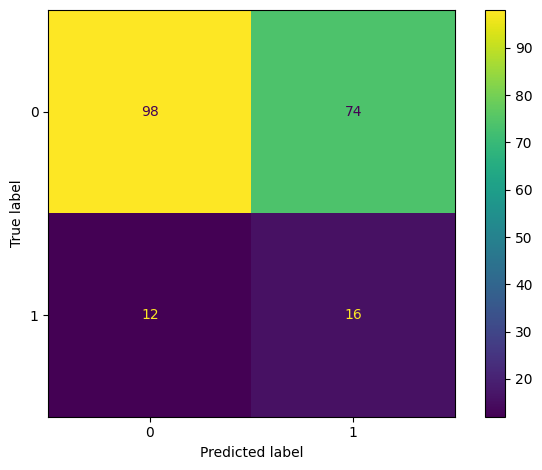

In [107]:
#create confusion matrix for logistic regression
ConfusionMatrixDisplay.from_predictions(y_test, predictions_regression)

plt.tight_layout()
plt.show()

Two versions of the logistic regression model were compared: a baseline model and a version using class_weight="balanced" to address the class imbalance in the target variable.
The baseline model reached 86% accuracy, but completely failed to identify dropout cases (precision, recall, and F1-score of 0.00 for Dropout=1). This illustrates a common pitfall in imbalanced classification problems: accuracy alone can be misleading, since a model that always predicts the majority class will still score well on this metric while providing no real predictive value for the minority class.
After balancing, recall for Dropout=1 increased to 0.57, meaning the model now correctly identifies more than half of the dropout cases. This came at the cost of precision (0.18) and overall accuracy (0.57), reflecting the trade-off between sensitivity and specificity when correcting for class imbalance.
Given the goal of this analysis — identifying participants at risk of dropping out — the balanced model is more useful in practice, despite its lower accuracy. Overall, both versions show limited discriminative power from the available clinical variables, consistent with the weak associations found in the earlier statistical tests.

### Decision Tree

In [108]:
#import
from sklearn.tree import DecisionTreeClassifier

#creating the Decision Tree model with class_weight="balanced" to address class imbalance
decisiontree_model = DecisionTreeClassifier(class_weight="balanced", random_state=42)

#training the model (note: Decision Tree doesn't require scaled data, unlike Logistic Regression)
decisiontree_model.fit(x_train, y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [109]:
#predicting on test set and checking accuracy
predictions_decisiontree = decisiontree_model.predict(x_test)

display("Decision Tree", accuracy_score(y_test, predictions_decisiontree))

'Decision Tree'

0.775

In [110]:
#adding Decision Tree predictions and dropout probabilities for the new patients
new_patients["Pred_decisiontree"] = decisiontree_model.predict(new_patients_features)
new_patients["Prob_decisiontree"] = decisiontree_model.predict_proba(new_patients_features)[:,1]

display(new_patients)

,Site_ID,Age,Adverse_Events,Systolic_BP,Diastolic_BP,Cholesterol_Level,Gender_Male,Treatment_Group_Drug B,Treatment_Group_Placebo,Pred_regression,Prob_regression,Pred_decisiontree,Prob_decisiontree
0,12,34,0,118,76,182,False,False,False,1,0.520518,0,0.0
1,8,58,2,145,90,236,True,True,False,0,0.418113,0,0.0
2,21,47,1,130,82,205,False,False,True,0,0.458709,0,0.0
3,5,69,4,162,98,264,True,False,False,0,0.328576,0,0.0
4,30,51,0,122,78,191,False,True,False,1,0.541163,1,1.0
5,17,40,2,135,84,214,True,False,True,0,0.408198,0,0.0
6,3,62,3,155,95,249,True,False,False,0,0.358768,0,0.0
7,11,29,0,112,72,176,False,True,False,1,0.553348,0,0.0
8,26,56,2,148,91,238,True,False,True,0,0.382295,0,0.0
9,14,44,1,128,80,198,False,False,False,0,0.480213,1,1.0


In [111]:
#evaluating decision tree performance on the test set
print("Decision Tree")
print(classification_report(y_test, predictions_decisiontree))

Decision Tree
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       172
           1       0.23      0.25      0.24        28

    accuracy                           0.78       200
   macro avg       0.55      0.56      0.55       200
weighted avg       0.78      0.78      0.78       200



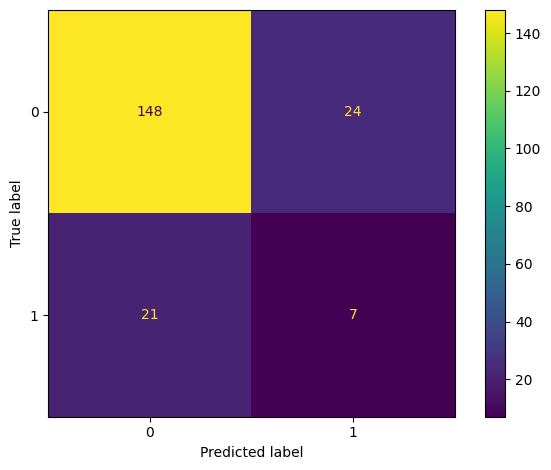

In [112]:
#create confusion matrix for decision tree
ConfusionMatrixDisplay.from_predictions(y_test, predictions_decisiontree)

plt.tight_layout()
plt.show()

The Decision Tree model was trained without depth restriction and with class_weight="balanced", following the same class-balancing approach used for Logistic Regression. It achieved an accuracy of 0.78, with a recall of 0.25 and precision of 0.23 for the Dropout class.
Unlike Logistic Regression — a linear model where class balancing produced a substantial shift in recall (from 0.00 to 0.57) — the unrestricted Decision Tree shows a much smaller apparent effect from class weighting. This is because an unpruned tree can already separate the training data almost perfectly regardless of how splits are weighted, which limits the practical influence of class_weight in this case. This is a useful illustration of how the effect of class balancing depends on model complexity: it matters more for models with limited flexibility (like linear models or shallow trees) than for models that can already overfit the training data freely.

### Random Forest

In [113]:
from sklearn.ensemble import RandomForestClassifier

#creating the Random Forest model with class_weight="balanced_subsample" (rebalances classes within each tree's bootstrap sample)
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced_subsample")

#training the model (also uses unscaled data, like Decision Tree)
rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [114]:
#predicting on test set and checking accuracy
predictions_rf = rf_model.predict(x_test)

display("Random Forest", accuracy_score(y_test, predictions_rf))

'Random Forest'

0.86

In [115]:
#adding random forest predictions and dropout probabilities for the new patients
new_patients["Pred_rf"] = rf_model.predict(new_patients_features)
new_patients["Prob_rf"] = rf_model.predict_proba(new_patients_features)[:,1]

display(new_patients)

,Site_ID,Age,Adverse_Events,Systolic_BP,Diastolic_BP,Cholesterol_Level,Gender_Male,Treatment_Group_Drug B,Treatment_Group_Placebo,Pred_regression,Prob_regression,Pred_decisiontree,Prob_decisiontree,Pred_rf,Prob_rf
0,12,34,0,118,76,182,False,False,False,1,0.520518,0,0.0,0,0.17
1,8,58,2,145,90,236,True,True,False,0,0.418113,0,0.0,0,0.03
2,21,47,1,130,82,205,False,False,True,0,0.458709,0,0.0,0,0.07
3,5,69,4,162,98,264,True,False,False,0,0.328576,0,0.0,0,0.09
4,30,51,0,122,78,191,False,True,False,1,0.541163,1,1.0,0,0.18
5,17,40,2,135,84,214,True,False,True,0,0.408198,0,0.0,0,0.09
6,3,62,3,155,95,249,True,False,False,0,0.358768,0,0.0,0,0.11
7,11,29,0,112,72,176,False,True,False,1,0.553348,0,0.0,0,0.21
8,26,56,2,148,91,238,True,False,True,0,0.382295,0,0.0,0,0.04
9,14,44,1,128,80,198,False,False,False,0,0.480213,1,1.0,0,0.17


In [ ]:
#evaluating random forest performance on the test set
print("Random Forest")
print(classification_report(y_test, predictions_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       172
           1       0.00      0.00      0.00        28

    accuracy                           0.86       200
   macro avg       0.43      0.50      0.46       200
weighted avg       0.74      0.86      0.80       200



c:\Users\MARQUES\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MARQUES\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MARQUES\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

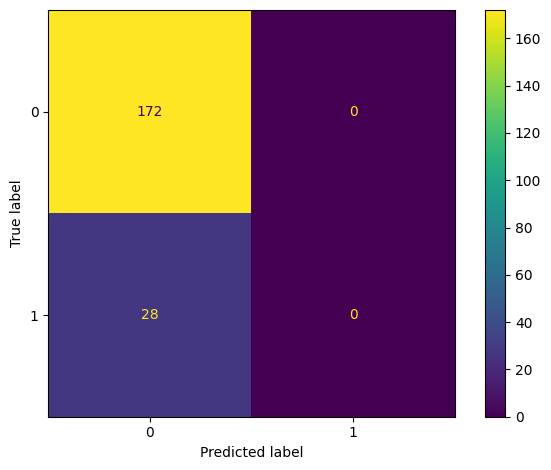

In [117]:
#create confusion matrix for random forest
ConfusionMatrixDisplay.from_predictions(y_test, predictions_rf)

plt.tight_layout()
plt.show()

Unlike Logistic Regression, applying class_weight="balanced" (and balanced_subsample) to the Random Forest model had no effect on its ability to identify Dropout cases — recall, precision, and F1-score for Dropout=1 remained at 0.00, identical to an unweighted model. This suggests that with weak underlying signal in the available features (consistent with the earlier statistical tests), the Random Forest's ensemble voting mechanism converges toward the majority class regardless of class weighting, unlike simpler models that can be pushed toward the minority class more directly.

### Models Comparison

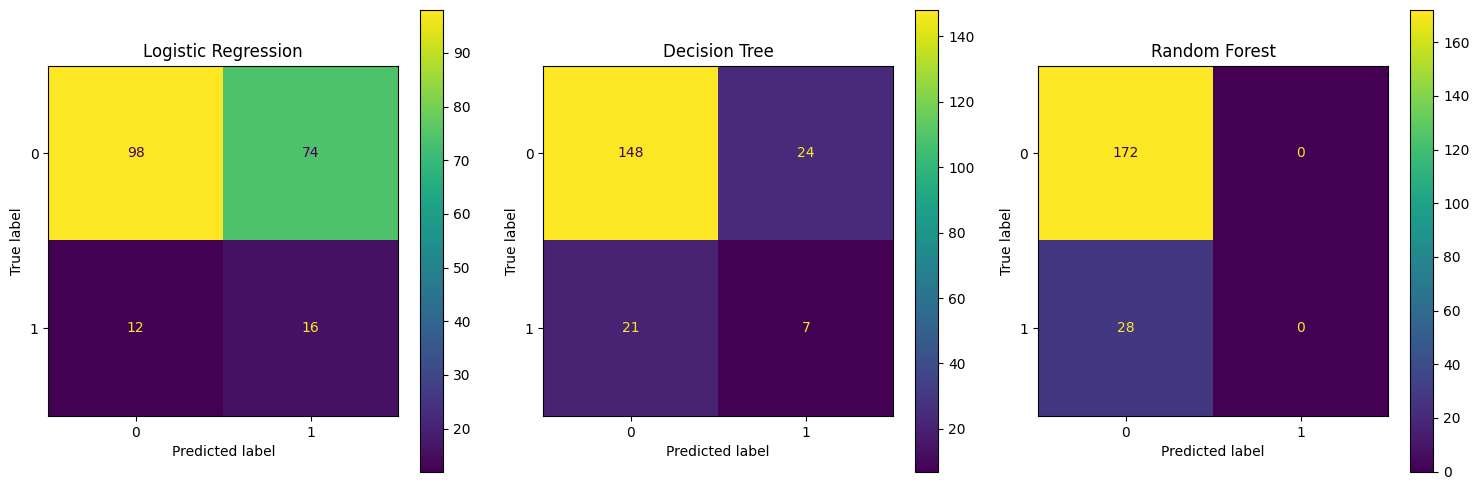

In [118]:
#comparing confusion matrices of the three models side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ConfusionMatrixDisplay.from_predictions(y_test, predictions_regression, ax=axes[0])
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, predictions_decisiontree, ax=axes[1])
axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay.from_predictions(y_test, predictions_rf, ax=axes[2])
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

In [119]:
#building a summary table to compare accuracy, recall and precision across all three models
from sklearn.metrics import recall_score, precision_score

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, predictions_regression),
        accuracy_score(y_test, predictions_decisiontree),
        accuracy_score(y_test, predictions_rf),
    ],
    "Recall (Dropout=1)": [
        recall_score(y_test, predictions_regression, zero_division=0),
        recall_score(y_test, predictions_decisiontree, zero_division=0),
        recall_score(y_test, predictions_rf, zero_division=0),
    ],
    "Precision (Dropout=1)": [
        precision_score(y_test, predictions_regression, zero_division=0),
        precision_score(y_test, predictions_decisiontree, zero_division=0),
        precision_score(y_test, predictions_rf, zero_division=0),
    ],
}).set_index("Model")

display(comparison_df.round(3))

,Accuracy,Recall (Dropout=1),Precision (Dropout=1)
Model,,,
Logistic Regression,0.570,0.571,0.178
Decision Tree,0.775,0.250,0.226
Random Forest,0.860,0.000,0.000


Three models were compared after applying class_weight="balanced": Logistic Regression, Decision Tree, and Random Forest. Despite being the simplest model, Logistic Regression achieved the highest recall for the Dropout class (0.57), while Random Forest, despite the highest overall accuracy (0.86), failed to identify any dropout cases at all (recall 0.00), even after testing class_weight="balanced_subsample".
This counterintuitive result is consistent with the weak feature-target associations found in the earlier statistical analysis: with limited signal in the data, Random Forest's ensemble voting mechanism converges toward the majority class regardless of class weighting, while the linear Logistic Regression model can be more directly pushed toward the minority class. Decision Tree fell between the two, with moderate recall (0.25) but limited practical gain from balancing, since an unpruned tree can already separate the training data almost perfectly.
Given these results, Logistic Regression was selected for further refinement through decision threshold tuning, explored in the next section.

### Decision Threshold Tuning
The default classification threshold of 0.5 is not necessarily optimal for this problem. In a clinical trial context, failing to identify a participant at risk of dropout (a false negative) is more costly than incorrectly flagging a participant who would have remained in the study (a false positive), a missed dropout represents lost data, reduced statistical power, and wasted recruitment investment, while a false positive simply triggers unnecessary outreach.
This asymmetry justifies exploring thresholds other than the default 0.5 to better align the model's predictions with this clinical priority, rather than relying solely on the standard decision boundary.

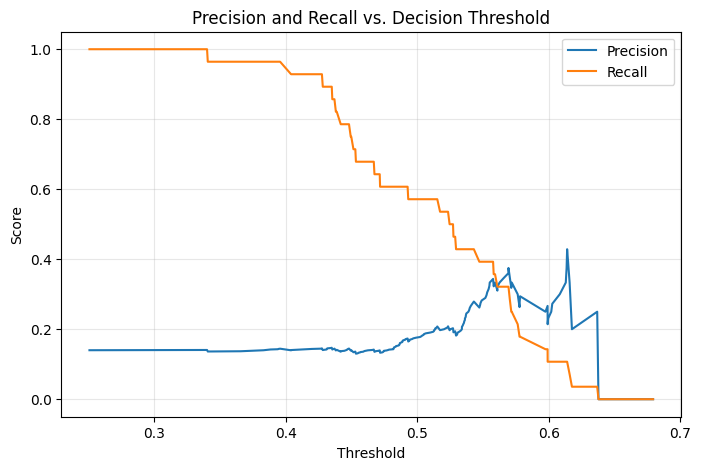

In [120]:
#plotting precision and recall at different thresholds to find a better cutoff than the default 0.5
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, probability_regression)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Decision Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [121]:
#finding the threshold that maximizes F1-score, then checking its performance
from sklearn.metrics import f1_score

f1_scores = [f1_score(y_test, (probability_regression >= t).astype(int), zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Best threshold (max F1): {best_threshold:.3f}")

predictions_best_f1 = (probability_regression >= best_threshold).astype(int)
print(classification_report(y_test, predictions_best_f1, zero_division=0))

Best threshold (max F1): 0.558
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       172
           1       0.34      0.39      0.37        28

    accuracy                           0.81       200
   macro avg       0.62      0.64      0.63       200
weighted avg       0.82      0.81      0.82       200



In [122]:
#threshold selected based on the clinical priority of recall, as discussed in the threshold analysis below 0.5
final_threshold = 0.5
predictions_final = (probability_regression >= final_threshold).astype(int)

print(f"Selected threshold = {final_threshold}")
print(classification_report(y_test, predictions_final, zero_division=0))

Selected threshold = 0.5
              precision    recall  f1-score   support

           0       0.89      0.57      0.70       172
           1       0.18      0.57      0.27        28

    accuracy                           0.57       200
   macro avg       0.53      0.57      0.48       200
weighted avg       0.79      0.57      0.64       200



To evaluate whether prioritizing recall further would be worthwhile, given that missing an at-risk participant carries a higher clinical cost than a false alarm, thresholds below 0.5 were explored. However, in that range, precision dropped to approximately the dataset's baseline dropout rate (~14%), indicating the model stopped meaningfully discriminating between classes and was instead flagging most patients as at-risk regardless of actual signal.
The default threshold (0.5) was therefore retained as the practical choice: it preserves a reasonable recall (0.57) for identifying at-risk participants while still outperforming random guessing (precision 0.18, above the 14% baseline). The F1-optimized threshold (0.558) offers an alternative for contexts prioritizing alert reliability over maximum recall, achieving higher precision (0.34) at the cost of lower recall (0.39).

In [123]:
#extracting Logistic Regression coefficients and converting them to odds ratios for interpretation
coefficients = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": regression_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])
display(coefficients)

,Feature,Coefficient,Odds_Ratio
3,Systolic_BP,-0.167947,0.845399
4,Diastolic_BP,0.125997,1.134279
2,Adverse_Events,-0.079393,0.923677
5,Cholesterol_Level,-0.072398,0.930161
6,Gender_Male,-0.051977,0.949350
0,Site_ID,0.046322,1.047411
7,Treatment_Group_Drug B,0.045677,1.046737
8,Treatment_Group_Placebo,-0.043434,0.957496
1,Age,-0.032356,0.968162


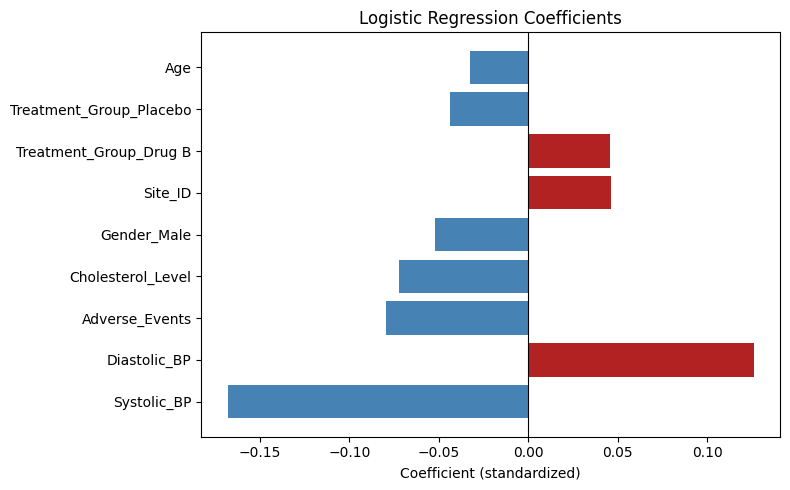

In [124]:
#visualizing the coefficients: red bars increase dropout odds, blue bars decrease them
plt.figure(figsize=(8,5))
colors = ["firebrick" if c > 0 else "steelblue" for c in coefficients["Coefficient"]]
plt.barh(coefficients["Feature"], coefficients["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (standardized)")
plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

The standardized logistic regression coefficients reveal small effect sizes across all features, consistent with the weak associations found during the exploratory analysis. Diastolic Blood Pressure shows a positive coefficient (0.126, odds ratio 1.13), aligning with the earlier t-test that identified it as the only statistically significant predictor in the univariate analysis.
Interestingly, Systolic Blood Pressure shows the largest coefficient magnitude (-0.168) despite not being statistically significant in the univariate t-test (p = 0.257). This discrepancy likely reflects the difference between univariate and multivariate analysis: the logistic regression coefficient captures the effect of Systolic BP while controlling for other correlated variables (including Diastolic BP), whereas the t-test evaluated it in isolation. Given the overall weak signal in this dataset, this coefficient should be interpreted with caution rather than as strong evidence of a systolic blood pressure effect.
Overall, no feature shows a coefficient large enough to indicate strong individual predictive power, reinforcing the conclusion that dropout in this synthetic dataset is not strongly explained by the available clinical variables alone.

## Limitations

- **Synthetic dataset:** the data is synthetic (Kaggle), not real clinical trial data, patterns found here should not be interpreted as clinically validated or generalizable to real-world dropout dynamics.

- **Weak underlying signal:** statistical tests found only one variable (Diastolic Blood Pressure) significantly associated with dropout, with a small effect size. This limits how well any model can discriminate between classes, regardless of complexity, and is the most likely explanation for the modest performance across all three algorithms tested.

- **Small, imbalanced dataset without cross-validation:** with only 161 dropout cases and a single 80/20 train-test split, reported metrics may be sensitive to the specific split and random seed used, limiting the robustness of performance estimates.

- **Limited exploration of imbalance and tuning strategies:** `class_weight="balanced"` was the primary approach used to address class imbalance; other techniques and systematic hyperparameter search were not tested and might yield different results.

- **Correlation, not causation:** all associations identified are observational and should not be interpreted as evidence that any variable directly causes dropout.

# Conclusion

This project explored a synthetic clinical trial dataset to identify factors associated with participant dropout and build a predictive model to flag at-risk participants.

The EDA showed weak associations overall: only Diastolic Blood Pressure was statistically significant (p = 0.027), while Gender, Treatment Group, and enrollment month showed no association with dropout.

Three models were compared using class weighting. Logistic Regression achieved the best recall for dropout (0.57), Decision Tree reached 0.25, and Random Forest — despite the highest accuracy (0.86) — failed to detect any dropout cases (recall 0.00). This reflects the weak signal in the data: linear models respond better to class balancing than ensemble methods do in this scenario.

Class balancing was essential for Logistic Regression but had little effect on the other two models. Threshold tuning confirmed that the default 0.5 threshold was the best practical choice, since lowering it degraded precision toward the dataset's baseline rate.